# ResNet-50 Transfer Learning - HAM10000 Skin Lesion Classification

In [1]:
!pip install kagglehub -q
import kagglehub

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset downloaded to:", path)

import os
print("\nFiles:")
for f in os.listdir(path):
    print(" ", f)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset downloaded to: /kaggle/input/skin-cancer-mnist-ham10000

Files:
  hmnist_8_8_RGB.csv
  hmnist_28_28_RGB.csv
  HAM10000_images_part_1
  ham10000_images_part_1
  hmnist_8_8_L.csv
  HAM10000_images_part_2
  ham10000_images_part_2
  hmnist_28_28_L.csv
  HAM10000_metadata.csv


In [2]:
import os
import copy
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if hasattr(torch.backends, "mps"):
    print("MPS available:", torch.backends.mps.is_available())

PyTorch version: 2.10.0+cu128
CUDA available: True
MPS available: False


In [3]:
CSV_PATH = os.path.join(path, "HAM10000_metadata.csv")
IMG_DIR_1 = os.path.join(path, "HAM10000_images_part_1")
IMG_DIR_2 = os.path.join(path, "HAM10000_images_part_2")

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 35
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MODEL_SAVE_PATH = "resnet50_ham10000.pth"
FIGURES_DIR = "resnet50_figures"

os.makedirs(FIGURES_DIR, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)

Using device: cuda


## Load data

In [4]:
df = pd.read_csv(CSV_PATH)
df = df[["image_id", "dx"]].copy()

def get_image_path(image_id):
    p1 = os.path.join(IMG_DIR_1, f"{image_id}.jpg")
    p2 = os.path.join(IMG_DIR_2, f"{image_id}.jpg")
    if os.path.exists(p1):
        return p1
    if os.path.exists(p2):
        return p2
    return None

df["path"] = df["image_id"].apply(get_image_path)
df = df[df["path"].notnull()].reset_index(drop=True)

print("Usable images:", len(df))
print("\nClass distribution:")
print(df["dx"].value_counts())

Usable images: 10015

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [5]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["dx"])

num_classes = len(label_encoder.classes_)
print("\nLabel mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i}: {cls}")


Label mapping:
  0: akiec
  1: bcc
  2: bkl
  3: df
  4: mel
  5: nv
  6: vasc


## Train/val/test split

In [6]:
# same split as the other notebooks - 70/15/15
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

Train: 7010  |  Val: 1502  |  Test: 1503


## Dataset + DataLoaders

In [7]:
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        label = int(row["label"])
        if self.transform:
            img = self.transform(img)
        return img, label

In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_dataset = HAM10000Dataset(train_df, transform=train_transform)
val_dataset = HAM10000Dataset(val_df, transform=eval_transform)
test_dataset = HAM10000Dataset(test_df, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 220
Val batches:   47
Test batches:  47


## Class weights

nv is like 67% of the dataset so we need to balance this out

In [9]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("Class weights:")
for i, w in enumerate(class_weights):
    print(f"  {label_encoder.classes_[i]:>5s}: {w:.3f}")

Class weights:
  akiec: 4.373
    bcc: 2.782
    bkl: 1.302
     df: 12.363
    mel: 1.286
     nv: 0.213
   vasc: 10.115


## Model setup

Using pretrained ResNet-50 from torchvision, swapping out the last FC layer for our 7 classes. Using dropout to help with overfitting since the dataset is pretty small.

In [10]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# swap out final layer
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, num_classes)
)

model = model.to(DEVICE)

print(f"Final layer: {num_features} -> {num_classes} classes")
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 180MB/s]


Final layer: 2048 -> 7 classes
Total params: 23,522,375
Trainable params: 23,522,375


In [12]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

## Training

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            probs = torch.softmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return (
        running_loss / total,
        correct / total,
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs)
    )

In [14]:
best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc = 0.0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        print(f"  >> New best val accuracy: {val_acc:.4f}")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")
model.load_state_dict(best_model_wts)

Epoch 1/35
  Train Loss: 1.4890 | Train Acc: 0.5679
  Val   Loss: 1.0057 | Val   Acc: 0.7117
  >> New best val accuracy: 0.7117
Epoch 2/35
  Train Loss: 0.9830 | Train Acc: 0.6549
  Val   Loss: 0.9095 | Val   Acc: 0.6638
Epoch 3/35
  Train Loss: 0.8523 | Train Acc: 0.6832
  Val   Loss: 0.7262 | Val   Acc: 0.8036
  >> New best val accuracy: 0.8036
Epoch 4/35
  Train Loss: 0.7226 | Train Acc: 0.7251
  Val   Loss: 0.6289 | Val   Acc: 0.7350
Epoch 5/35
  Train Loss: 0.6316 | Train Acc: 0.7298
  Val   Loss: 0.6134 | Val   Acc: 0.7224
Epoch 6/35
  Train Loss: 0.6001 | Train Acc: 0.7358
  Val   Loss: 0.6736 | Val   Acc: 0.7949
Epoch 7/35
  Train Loss: 0.5628 | Train Acc: 0.7521
  Val   Loss: 0.5646 | Val   Acc: 0.7876
Epoch 8/35
  Train Loss: 0.5033 | Train Acc: 0.7745
  Val   Loss: 0.5986 | Val   Acc: 0.7963
Epoch 9/35
  Train Loss: 0.4590 | Train Acc: 0.7899
  Val   Loss: 0.6331 | Val   Acc: 0.8229
  >> New best val accuracy: 0.8229
Epoch 10/35
  Train Loss: 0.4396 | Train Acc: 0.7936
  Val

<All keys matched successfully>

In [15]:
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}")

Model saved to resnet50_ham10000.pth


## Training curves

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label="Train Loss")
ax1.plot(val_losses, label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training and Validation Loss")
ax1.legend()

ax2.plot(train_accs, label="Train Accuracy")
ax2.plot(val_accs, label="Val Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Training and Validation Accuracy")
ax2.legend()

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/training_curves.png", dpi=300, bbox_inches="tight")
plt.show()

## Test evaluation

In [16]:
test_loss, test_acc, y_true, y_pred, y_probs = evaluate(model, test_loader, criterion, DEVICE)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

mel_index = label_encoder.transform(["mel"])[0]
mel_mask = (y_true == mel_index)
mel_recall = (y_pred[mel_mask] == mel_index).sum() / mel_mask.sum()
print(f"Melanoma Recall: {mel_recall:.4f}")

Test Loss: 0.8393
Test Accuracy: 0.8736

Classification Report:
              precision    recall  f1-score   support

       akiec       0.57      0.73      0.64        49
         bcc       0.81      0.88      0.84        77
         bkl       0.80      0.67      0.73       165
          df       0.86      0.71      0.77        17
         mel       0.73      0.62      0.67       167
          nv       0.93      0.96      0.94      1006
        vasc       0.81      0.95      0.88        22

    accuracy                           0.87      1503
   macro avg       0.79      0.79      0.78      1503
weighted avg       0.87      0.87      0.87      1503

Melanoma Recall: 0.6228


## Confusion matrices

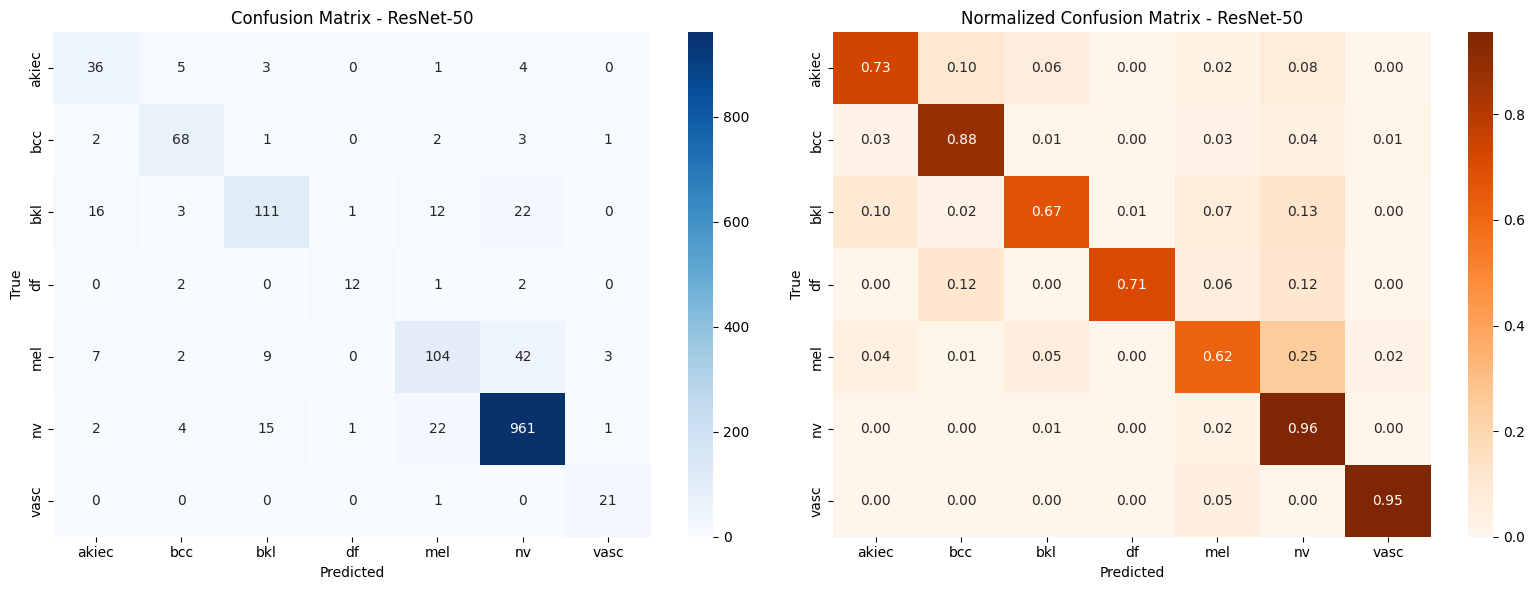

In [17]:
cm = confusion_matrix(y_true, y_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=ax1)
ax1.set_xlabel("Predicted")
ax1.set_ylabel("True")
ax1.set_title("Confusion Matrix - ResNet-50")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Oranges",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=ax2)
ax2.set_xlabel("Predicted")
ax2.set_ylabel("True")
ax2.set_title("Normalized Confusion Matrix - ResNet-50")

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

## Per-class metrics

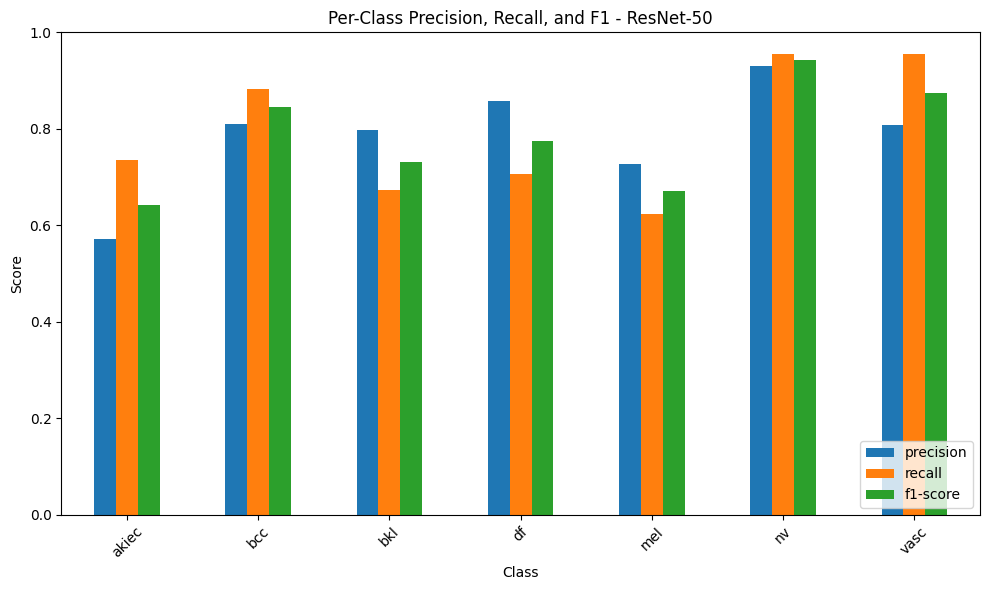

In [18]:
report = classification_report(y_true, y_pred, target_names=label_encoder.classes_, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df = report_df.loc[label_encoder.classes_, ["precision", "recall", "f1-score"]]

fig, ax = plt.subplots(figsize=(10, 6))
report_df.plot(kind="bar", ax=ax)
plt.title("Per-Class Precision, Recall, and F1 - ResNet-50")
plt.xlabel("Class")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/per_class_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

## Melanoma analysis

This is the most important class clinically - we want to minimize false negatives here

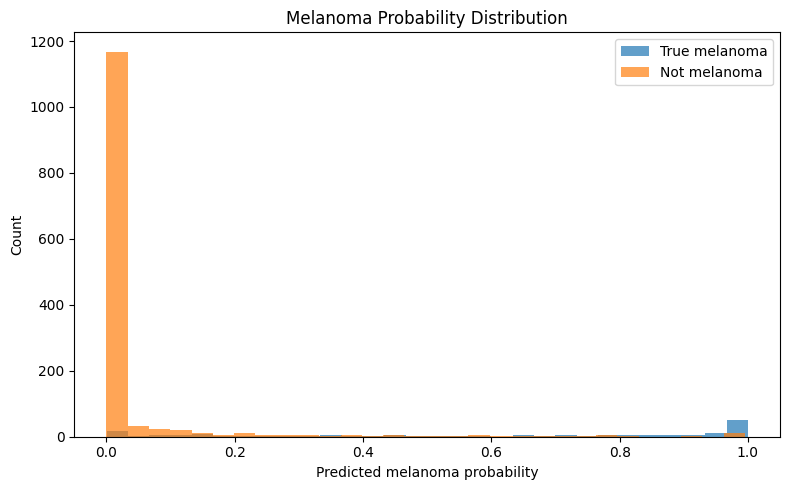

In [19]:
mel_probs = y_probs[:, mel_index]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(mel_probs[y_true == mel_index], bins=30, alpha=0.7, label="True melanoma")
ax.hist(mel_probs[y_true != mel_index], bins=30, alpha=0.7, label="Not melanoma")
ax.set_xlabel("Predicted melanoma probability")
ax.set_ylabel("Count")
ax.set_title("Melanoma Probability Distribution")
ax.legend()
plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/melanoma_prob_dist.png", dpi=300, bbox_inches="tight")
plt.show()

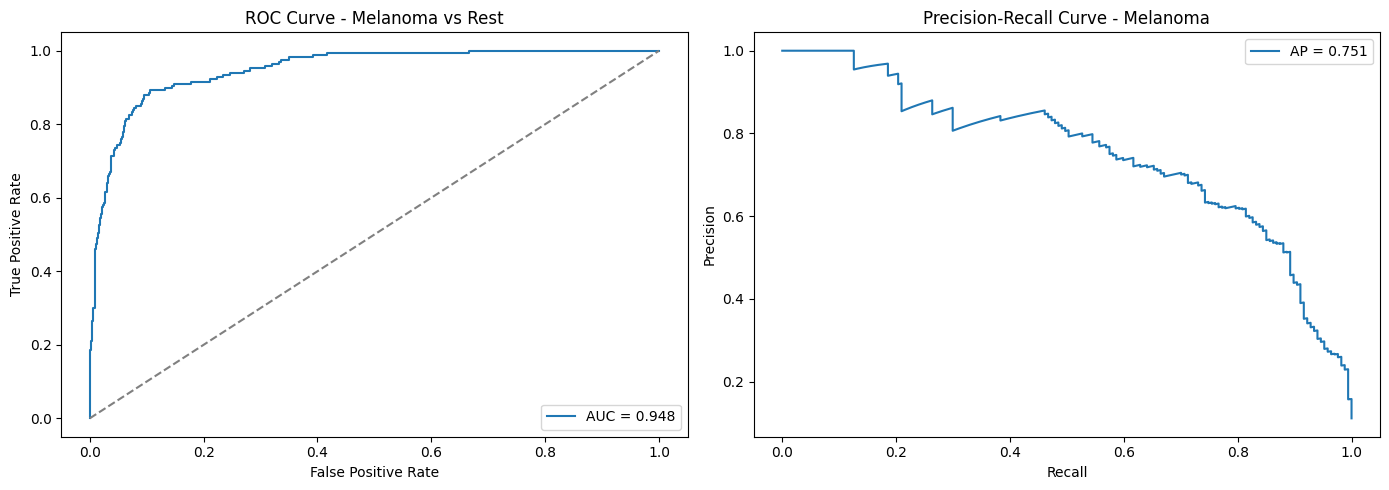

In [20]:
# ROC and PR curves for melanoma
y_true_mel = (y_true == mel_index).astype(int)
fpr, tpr, _ = roc_curve(y_true_mel, mel_probs)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_true_mel, mel_probs)
ap = average_precision_score(y_true_mel, mel_probs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
ax1.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve - Melanoma vs Rest")
ax1.legend(loc="lower right")

ax2.plot(recall, precision, label=f"AP = {ap:.3f}")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve - Melanoma")
ax2.legend()

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/roc_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()

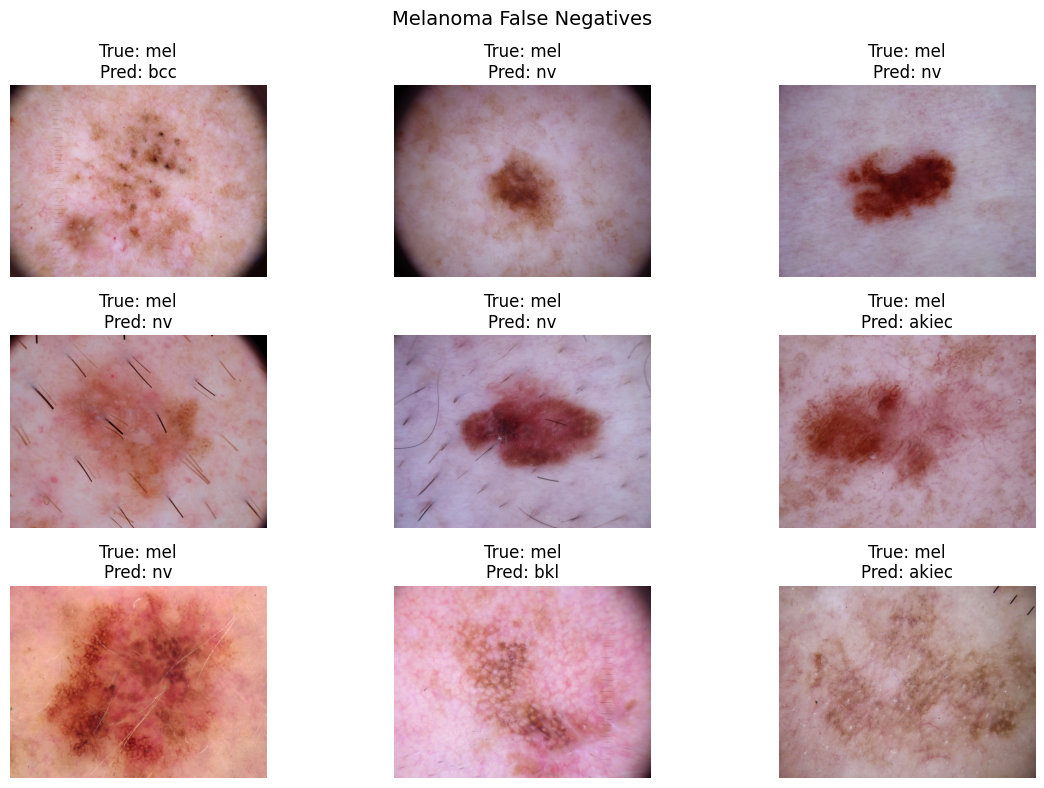

Total melanoma false negatives: 63 / 167


In [21]:
# melanoma false negatives - these are the dangerous misses
fn_indices = np.where((y_true == mel_index) & (y_pred != mel_index))[0]

num_show = min(9, len(fn_indices))
fig = plt.figure(figsize=(12, 8))

for i, idx in enumerate(fn_indices[:num_show]):
    plt.subplot(3, 3, i + 1)
    img = Image.open(test_df.iloc[idx]["path"]).convert("RGB")
    plt.imshow(img)

    true_label = label_encoder.inverse_transform([y_true[idx]])[0]
    pred_label = label_encoder.inverse_transform([y_pred[idx]])[0]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.suptitle("Melanoma False Negatives", fontsize=14)
plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/melanoma_false_negatives.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Total melanoma false negatives: {len(fn_indices)} / {mel_mask.sum()}")

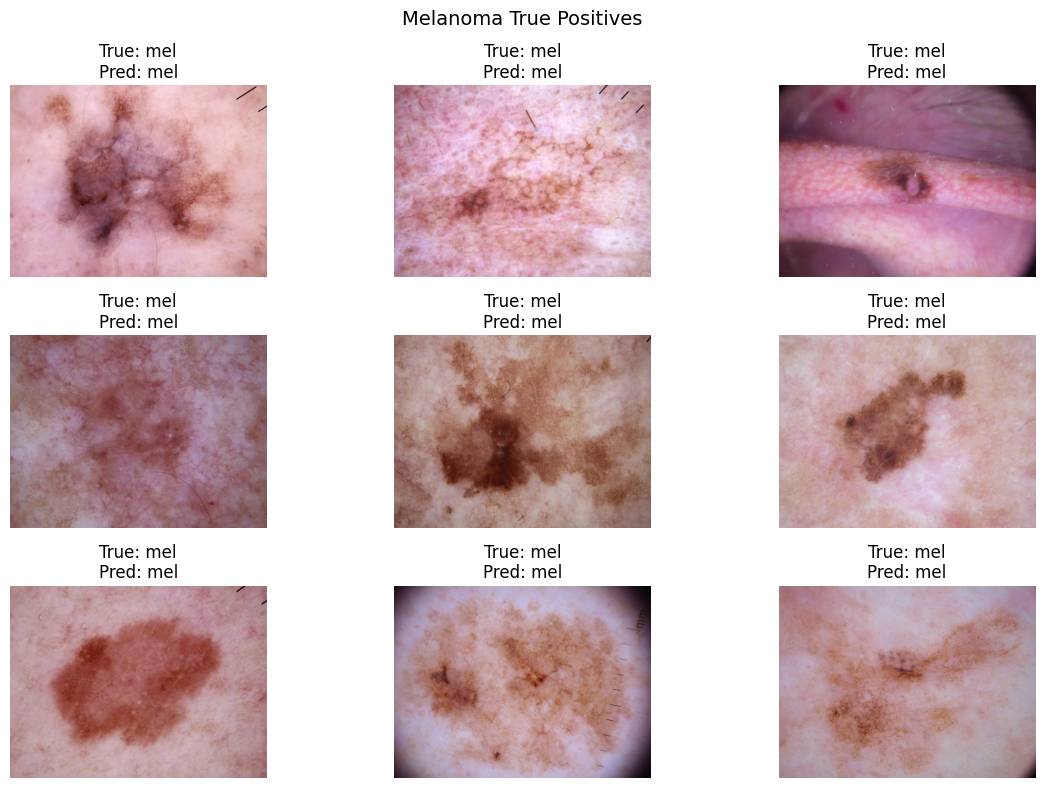

Total melanoma true positives: 104 / 167


In [22]:
tp_indices = np.where((y_true == mel_index) & (y_pred == mel_index))[0]

num_show = min(9, len(tp_indices))
fig = plt.figure(figsize=(12, 8))

for i, idx in enumerate(tp_indices[:num_show]):
    plt.subplot(3, 3, i + 1)
    img = Image.open(test_df.iloc[idx]["path"]).convert("RGB")
    plt.imshow(img)

    true_label = label_encoder.inverse_transform([y_true[idx]])[0]
    pred_label = label_encoder.inverse_transform([y_pred[idx]])[0]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.suptitle("Melanoma True Positives", fontsize=14)
plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/melanoma_true_positives.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Total melanoma true positives: {len(tp_indices)} / {mel_mask.sum()}")

## Most confused class pairs

In [23]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

pairs = []
for i in range(cm_no_diag.shape[0]):
    for j in range(cm_no_diag.shape[1]):
        if cm_no_diag[i, j] > 0:
            pairs.append((label_encoder.classes_[i], label_encoder.classes_[j], cm_no_diag[i, j]))

pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
confused_df = pd.DataFrame(pairs[:10], columns=["True Class", "Predicted Class", "Count"])
print(confused_df.to_string(index=False))

True Class Predicted Class  Count
       mel              nv     42
       bkl              nv     22
        nv             mel     22
       bkl           akiec     16
        nv             bkl     15
       bkl             mel     12
       mel             bkl      9
       mel           akiec      7
     akiec             bcc      5
     akiec              nv      4


## Sample predictions

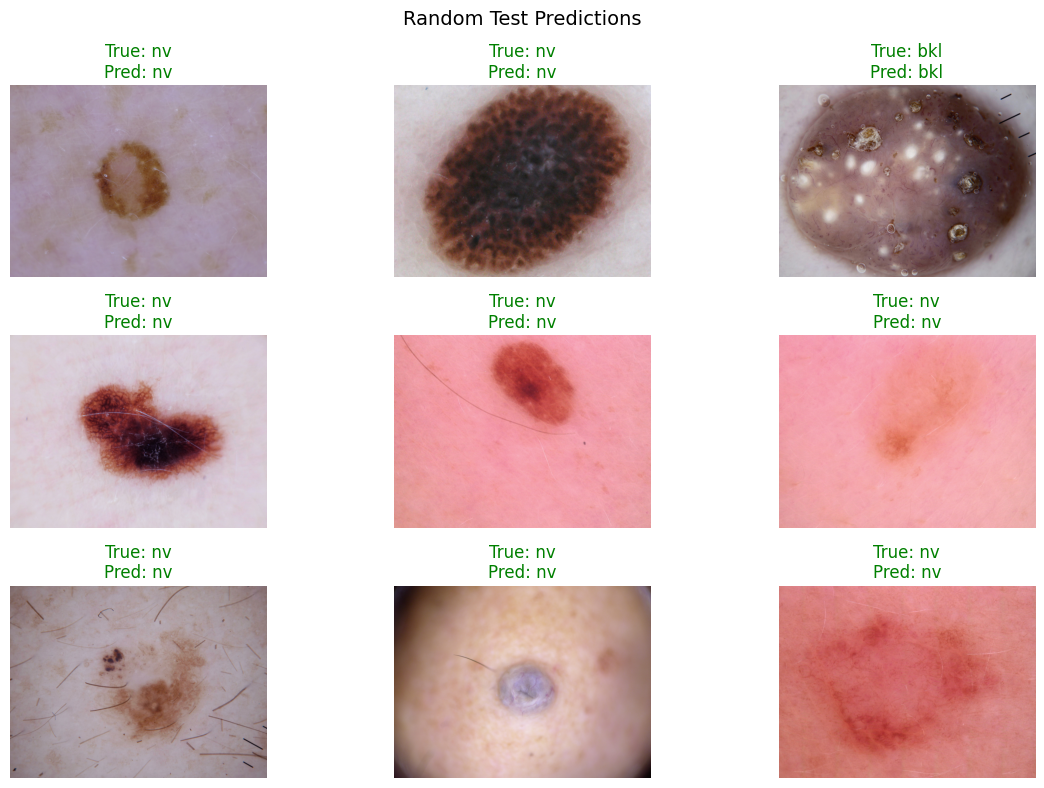

In [24]:
np.random.seed(42)
sample_indices = np.random.choice(len(y_true), size=9, replace=False)

fig = plt.figure(figsize=(12, 8))
for i, idx in enumerate(sample_indices):
    plt.subplot(3, 3, i + 1)
    img = Image.open(test_df.iloc[idx]["path"]).convert("RGB")
    plt.imshow(img)

    true_label = label_encoder.inverse_transform([y_true[idx]])[0]
    pred_label = label_encoder.inverse_transform([y_pred[idx]])[0]
    color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis("off")

plt.suptitle("Random Test Predictions", fontsize=14)
plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/sample_predictions.png", dpi=300, bbox_inches="tight")
plt.show()

## Comparison with other models

              Model  Test Accuracy  Melanoma Recall
Logistic Regression       0.629000         0.320000
      Random Forest       0.700000         0.030000
         Simple CNN       0.628000         0.455000
          ResNet-50       0.873586         0.622754


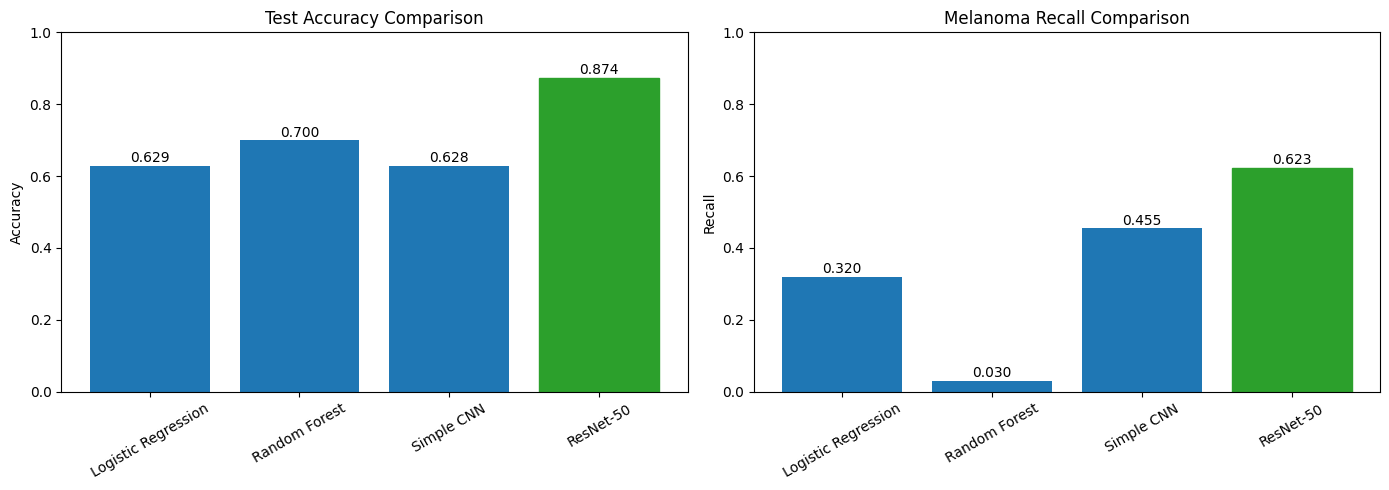

In [26]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Simple CNN", "ResNet-50"],
    "Test Accuracy": [0.629, 0.700, 0.628, test_acc],
    "Melanoma Recall": [0.32, 0.03, 0.455, float(mel_recall)],
})

print(comparison.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(comparison["Model"], comparison["Test Accuracy"])
bars1[-1].set_color("tab:green")
ax1.set_ylabel("Accuracy")
ax1.set_title("Test Accuracy Comparison")
ax1.set_ylim(0, 1)
ax1.tick_params(axis="x", rotation=30)
for bar, val in zip(bars1, comparison["Test Accuracy"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", fontsize=10)

bars2 = ax2.bar(comparison["Model"], comparison["Melanoma Recall"])
bars2[-1].set_color("tab:green")
ax2.set_ylabel("Recall")
ax2.set_title("Melanoma Recall Comparison")
ax2.set_ylim(0, 1)
ax2.tick_params(axis="x", rotation=30)
for bar, val in zip(bars2, comparison["Melanoma Recall"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", fontsize=10)

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Results summary

In [27]:
full_report = classification_report(y_true, y_pred, target_names=label_encoder.classes_, output_dict=True)
results_df = pd.DataFrame(full_report).transpose()

print(f"Model: ResNet-50 (pretrained ImageNet, fine-tuned)")
print(f"Epochs: {NUM_EPOCHS} | Batch Size: {BATCH_SIZE} | LR: {LEARNING_RATE}")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Best Val Accuracy: {best_val_acc:.4f}")
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Melanoma Recall: {mel_recall:.4f}")
print(f"Melanoma ROC AUC: {roc_auc:.4f}")
print(f"Melanoma Avg Precision: {ap:.4f}")

print("\nPer-Class Results:")
print(results_df.to_string())

print("\nModel Comparison:")
print(comparison.to_string(index=False))

# save tables as csv too
results_df.to_csv(f"{FIGURES_DIR}/classification_report.csv")
comparison.to_csv(f"{FIGURES_DIR}/model_comparison.csv", index=False)

Model: ResNet-50 (pretrained ImageNet, fine-tuned)
Epochs: 35 | Batch Size: 32 | LR: 0.0001
Image Size: 224x224
Best Val Accuracy: 0.8895

Test Accuracy: 0.8736
Melanoma Recall: 0.6228
Melanoma ROC AUC: 0.9484
Melanoma Avg Precision: 0.7513

Per-Class Results:
              precision    recall  f1-score      support
akiec          0.571429  0.734694  0.642857    49.000000
bcc            0.809524  0.883117  0.844720    77.000000
bkl            0.798561  0.672727  0.730263   165.000000
df             0.857143  0.705882  0.774194    17.000000
mel            0.727273  0.622754  0.670968   167.000000
nv             0.929400  0.955268  0.942157  1006.000000
vasc           0.807692  0.954545  0.875000    22.000000
accuracy       0.873586  0.873586  0.873586     0.873586
macro avg      0.785860  0.789856  0.782880  1503.000000
weighted avg   0.872168  0.873586  0.871131  1503.000000

Model Comparison:
              Model  Test Accuracy  Melanoma Recall
Logistic Regression       0.629000       

In [28]:
print("Saved figures:")
for f in sorted(os.listdir(FIGURES_DIR)):
    size = os.path.getsize(os.path.join(FIGURES_DIR, f))
    print(f"  {f} ({size/1024:.1f} KB)")

Saved figures:
  classification_report.csv (0.7 KB)
  confusion_matrices.png (269.3 KB)
  melanoma_false_negatives.png (5758.5 KB)
  melanoma_prob_dist.png (86.5 KB)
  melanoma_true_positives.png (5656.5 KB)
  model_comparison.csv (0.2 KB)
  model_comparison.png (174.8 KB)
  per_class_metrics.png (103.0 KB)
  roc_pr_curves.png (183.0 KB)
  sample_predictions.png (5124.7 KB)


## Loading saved model

```python
model = models.resnet50(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(2048, 7)
)
model.load_state_dict(torch.load("resnet50_ham10000.pth", map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
```